In [1]:
# Renko Chart Analysis with Stochastic Oscillator

#This notebook builds a Renko chart from historical OHLC data, calculates technical indicators, and generates buy/sell signals based on renko bricks .
    

In [2]:
## 1. Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
## 2. Configuration Parameters
# Ticker and date range
ticker = 'ES=F'
start_date = '2025-2-01'
end_date = '2026-2-1'

# Renko brick size
brick_size = 15  # Adjust as needed

In [4]:
# Download OHLC data from Yahoo Finance
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns (fix for newer yfinance versions)
df.columns = df.columns.get_level_values(0)

# Keep only the essential columns
df = df[['Open', 'High', 'Low', 'Close']]

# Reset index to get Date as a column
df = df.reset_index()

# Display first few rows
df.head()

/var/folders/2v/mkg1tcnj0dsgbn4wspnx8l0h0000gn/T/ipykernel_32160/2983682258.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Date,Open,High,Low,Close
0,2025-02-03,5982.25,6062.00,5935.50,6022.25
1,2025-02-04,6069.00,6069.00,5987.00,6063.00
2,2025-02-05,6042.75,6092.00,6020.25,6086.50
3,2025-02-06,6090.25,6108.50,6070.00,6106.00
4,2025-02-07,6089.75,6123.25,6041.25,6049.50


In [5]:
# Convert Close prices and dates to lists
prices = df['Close'].values.flatten().tolist()
dates = df['Date'].tolist()

renko_data = []      # Stores price levels of each brick
directions = []      # 1 = up, -1 = down, 0 = neutral (first brick)
renko_dates = []     # Stores the date when each brick was formed

last_price = prices[0]
renko_data.append(last_price)
directions.append(0)
renko_dates.append(dates[0])

for idx, price in enumerate(prices):
    diff = price - last_price
    brick_moves = int(diff / brick_size)

    while brick_moves != 0:
        if brick_moves > 0:
            last_price += brick_size
            renko_data.append(last_price)
            directions.append(1)
            renko_dates.append(dates[idx])
            brick_moves -= 1
        elif brick_moves < 0:
            last_price -= brick_size
            renko_data.append(last_price)
            directions.append(-1)
            renko_dates.append(dates[idx])
            brick_moves += 1

print(f"Total Renko bricks: {len(renko_data)}")
print(f"Date range: {renko_dates[0]} to {renko_dates[-1]}")

Total Renko bricks: 634
Date range: 2025-02-03 00:00:00 to 2026-01-30 00:00:00


In [6]:
## 5. Calculate X and Y Positions for Bricks
x_positions = [0]
y_positions = [renko_data[0]]

for i in range(1, len(renko_data)):
    prev_x = x_positions[-1]
    prev_y = y_positions[-1]
    
    if renko_data[i] > renko_data[i-1]:
        x_positions.append(prev_x + 1)
        y_positions.append(prev_y + brick_size)
    else:
        x_positions.append(prev_x + 1)
        y_positions.append(prev_y - brick_size)

In [7]:
# Create DataFrame for Renko data
renko_df = pd.DataFrame({
    'X': x_positions,
    'Y': y_positions,
    'Price': renko_data,
    'Direction': directions,
    'Date': renko_dates
})

# Convert Date to datetime if not already
renko_df['Date'] = pd.to_datetime(renko_df['Date'])

# Calculate Moving Averages
renko_df['MA7'] = renko_df['Price'].rolling(window=7).mean()
renko_df['MA20'] = renko_df['Price'].rolling(window=20).mean()
renko_df['MA200'] = renko_df['Price'].rolling(window=200).mean()

# Calculate Stochastic Oscillator (10, 3, 3)
k_period = 10
d_period = 3
smooth_k = 3

renko_df['Lowest'] = renko_df['Price'].rolling(window=k_period).min()
renko_df['Highest'] = renko_df['Price'].rolling(window=k_period).max()
renko_df['%K'] = 100 * (renko_df['Price'] - renko_df['Lowest']) / (renko_df['Highest'] - renko_df['Lowest'])
renko_df['%K'] = renko_df['%K'].rolling(window=smooth_k).mean()
renko_df['%D'] = renko_df['%K'].rolling(window=d_period).mean()

# Store previous values for crossover detection
renko_df['%K_prev'] = renko_df['%K'].shift(1)
renko_df['%D_prev'] = renko_df['%D'].shift(1)
renko_df['Price_prev'] = renko_df['Price'].shift(1)
renko_df['MA7_prev'] = renko_df['MA7'].shift(1)

# Initialize Signal columns
renko_df['Signal'] = 0
renko_df['Exit_Signal'] = 0

# Display data availability info
first_valid_ma200 = renko_df['MA200'].first_valid_index()
print(f"Total Renko Bricks: {len(renko_df)}")
print(f"MA200 available from brick: {first_valid_ma200}")
print(f"Bricks available for trading: {len(renko_df) - first_valid_ma200}")
print(f"Date range: {renko_df['Date'].min().strftime('%Y-%m-%d')} to {renko_df['Date'].max().strftime('%Y-%m-%d')}")

renko_df.head(15)

Total Renko Bricks: 634
MA200 available from brick: 199
Bricks available for trading: 435
Date range: 2025-02-03 to 2026-01-30


,X,Y,Price,Direction,Date,MA7,MA20,MA200,Lowest,Highest,%K,%D,%K_prev,%D_prev,Price_prev,MA7_prev,Signal,Exit_Signal
0,0,6022.25,6022.25,0,2025-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,1,6037.25,6037.25,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6022.25,NaN,0,0
2,2,6052.25,6052.25,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6037.25,NaN,0,0
3,3,6067.25,6067.25,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6052.25,NaN,0,0
4,4,6082.25,6082.25,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6067.25,NaN,0,0
5,5,6097.25,6097.25,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6082.25,NaN,0,0
6,6,6082.25,6082.25,-1,2025-02-07,6062.964286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6097.25,NaN,0,0
7,7,6067.25,6067.25,-1,2025-02-07,6069.392857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6082.25,6062.964286,0,0
8,8,6052.25,6052.25,-1,2025-02-07,6071.535714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6067.25,6069.392857,0,0
9,9,6067.25,6067.25,1,2025-02-10,6073.678571,NaN,NaN,6022.25,6097.25,NaN,NaN,NaN,NaN,6052.25,6071.535714,0,0


In [8]:
## 7. Define Parameters and Generate Buy/Sell Signals Based on Renko Bricks
# Trading Parameters
initial_capital = 10000
risk_per_trade = 0.01   # 1% risk
position_size = 1       # We'll adjust this later

capital = initial_capital
equity_curve = []
trade_log = []

In [ ]:
### 7.1 Generate Trade Signals on Full Dataset (Long & Short Strategy)

#**Strategy Rules:**
#- **Long Entry:** Green brick above MA200 AND %K crosses above %D
#- **Long Exit:** Price crosses below MA7
#- **Short Entry:** Red brick below MA200 AND %K crosses below %D
#- **Short Exit:** Price crosses above MA7
# Reset trading parameters
capital = initial_capital
equity_curve = []
trade_log = []
daily_pnl = []  # Track daily PnL (change in equity per brick)
cumulative_pnl = []  # Track cumulative PnL

# Position tracking
in_long = False
in_short = False
entry_price = 0
position_size = 0
risk_amount = 0

# Signal counters
long_entry_count = 0
short_entry_count = 0
long_exit_count = 0
short_exit_count = 0

running_pnl = 0
previous_capital = initial_capital

for i in range(1, len(renko_df)):
    current_price = renko_df.loc[i, 'Price']
    prev_price = renko_df.loc[i, 'Price_prev']
    ma7 = renko_df.loc[i, 'MA7']
    ma7_prev = renko_df.loc[i, 'MA7_prev']
    ma200 = renko_df.loc[i, 'MA200']
    direction = renko_df.loc[i, 'Direction']
    current_date = renko_df.loc[i, 'Date']
    
    # Get stochastic values
    k_current = renko_df.loc[i, '%K']
    k_prev = renko_df.loc[i, '%K_prev']
    d_current = renko_df.loc[i, '%D']
    d_prev = renko_df.loc[i, '%D_prev']
    
    # Skip if any required values are NaN
    if pd.isna(ma200) or pd.isna(ma7) or pd.isna(k_prev) or pd.isna(d_prev):
        equity_curve.append(capital)
        daily_pnl.append(0)  # No change
        cumulative_pnl.append(running_pnl)
        previous_capital = capital
        continue
    
    # Detect stochastic crossovers
    stoch_cross_up = (k_prev < d_prev) and (k_current > d_current)
    stoch_cross_down = (k_prev > d_prev) and (k_current < d_current)
    
    # Track PnL for this brick
    brick_pnl = 0
    
    # ========== EXIT LOGIC (Check exits first) ==========
    
    # Exit Long: Price crosses below MA7
    if in_long:
        if prev_price >= ma7_prev and current_price < ma7:
            exit_price = current_price
            pnl = (exit_price - entry_price) * position_size
            capital += pnl
            running_pnl += pnl
            brick_pnl = pnl
            in_long = False
            long_exit_count += 1
            renko_df.loc[i, 'Exit_Signal'] = 1
            
            rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
            
            trade_log[-1].update({
                'Exit_Brick': i,
                'Exit_Price': exit_price,
                'Exit_Date': current_date,
                'PnL': pnl,
                'Capital': capital,
                'Risk_Amount': risk_amount,
                'RR_Ratio': rr_ratio
            })
    
    # Exit Short: Price crosses above MA7
    if in_short:
        if prev_price <= ma7_prev and current_price > ma7:
            exit_price = current_price
            pnl = (entry_price - exit_price) * position_size
            capital += pnl
            running_pnl += pnl
            brick_pnl = pnl
            in_short = False
            short_exit_count += 1
            renko_df.loc[i, 'Exit_Signal'] = -1
            
            rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
            
            trade_log[-1].update({
                'Exit_Brick': i,
                'Exit_Price': exit_price,
                'Exit_Date': current_date,
                'PnL': pnl,
                'Capital': capital,
                'Risk_Amount': risk_amount,
                'RR_Ratio': rr_ratio
            })
    
    # ========== ENTRY LOGIC ==========
    
    if not in_long and not in_short:
        
        # Long Entry: Green brick above MA200 AND %K crosses above %D
        if direction == 1 and current_price > ma200 and stoch_cross_up:
            entry_price = current_price
            risk_amount = capital * risk_per_trade
            position_size = risk_amount / brick_size
            in_long = True
            long_entry_count += 1
            renko_df.loc[i, 'Signal'] = 1
            trade_log.append({
                'Type': 'LONG',
                'Entry_Brick': i,
                'Entry_Price': entry_price,
                'Entry_Date': current_date,
                'Size': position_size,
                'Risk_Amount': risk_amount
            })
        
        # Short Entry: Red brick below MA200 AND %K crosses below %D
        elif direction == -1 and current_price < ma200 and stoch_cross_down:
            entry_price = current_price
            risk_amount = capital * risk_per_trade
            position_size = risk_amount / brick_size
            in_short = True
            short_entry_count += 1
            renko_df.loc[i, 'Signal'] = -1
            trade_log.append({
                'Type': 'SHORT',
                'Entry_Brick': i,
                'Entry_Price': entry_price,
                'Entry_Date': current_date,
                'Size': position_size,
                'Risk_Amount': risk_amount
            })
    
    # Calculate daily PnL (change from previous capital)
    daily_change = capital - previous_capital
    daily_pnl.append(daily_change)
    
    equity_curve.append(capital)
    cumulative_pnl.append(running_pnl)
    previous_capital = capital

# Close any open positions at the end
if in_long:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    pnl = (exit_price - entry_price) * position_size
    capital += pnl
    running_pnl += pnl
    long_exit_count += 1
    rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'PnL': pnl,
        'Capital': capital,
        'Risk_Amount': risk_amount,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] = pnl
        cumulative_pnl[-1] = running_pnl

if in_short:
    exit_price = renko_df.loc[len(renko_df) - 1, 'Price']
    pnl = (entry_price - exit_price) * position_size
    capital += pnl
    running_pnl += pnl
    short_exit_count += 1
    rr_ratio = pnl / risk_amount if risk_amount != 0 else 0
    trade_log[-1].update({
        'Exit_Brick': len(renko_df) - 1,
        'Exit_Price': exit_price,
        'Exit_Date': renko_df.loc[len(renko_df) - 1, 'Date'],
        'PnL': pnl,
        'Capital': capital,
        'Risk_Amount': risk_amount,
        'RR_Ratio': rr_ratio,
        'Note': 'Closed at end'
    })
    if equity_curve:
        equity_curve[-1] = capital
        daily_pnl[-1] = pnl
        cumulative_pnl[-1] = running_pnl

# Display signal counts
print("=" * 50)
print("           TRADE SIGNAL SUMMARY")
print("=" * 50)
print(f"Long Entry Signals:  {long_entry_count}")
print(f"Long Exit Signals:   {long_exit_count}")
print(f"Short Entry Signals: {short_entry_count}")
print(f"Short Exit Signals:  {short_exit_count}")
print("-" * 50)
print(f"Total Trades Executed: {len(trade_log)}")
print(f"  - Long Trades:  {len([t for t in trade_log if t['Type'] == 'LONG'])}")
print(f"  - Short Trades: {len([t for t in trade_log if t['Type'] == 'SHORT'])}")
print("=" * 50)

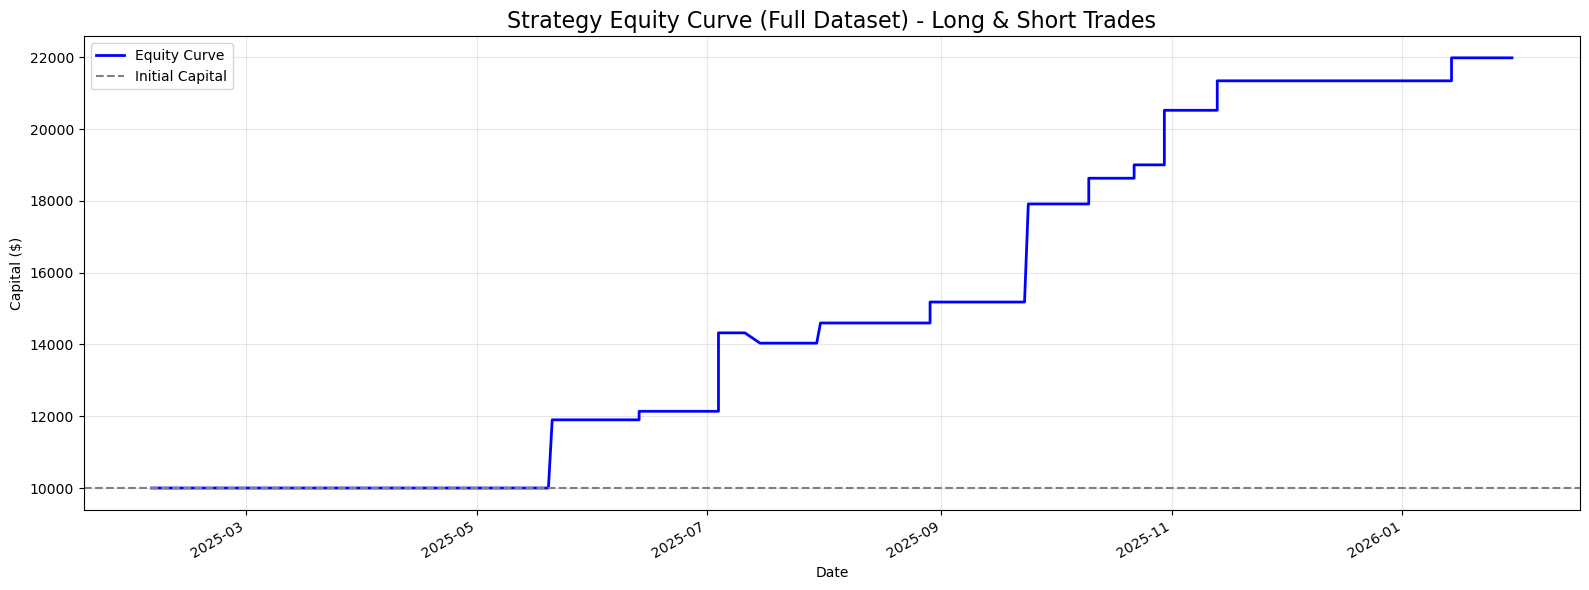

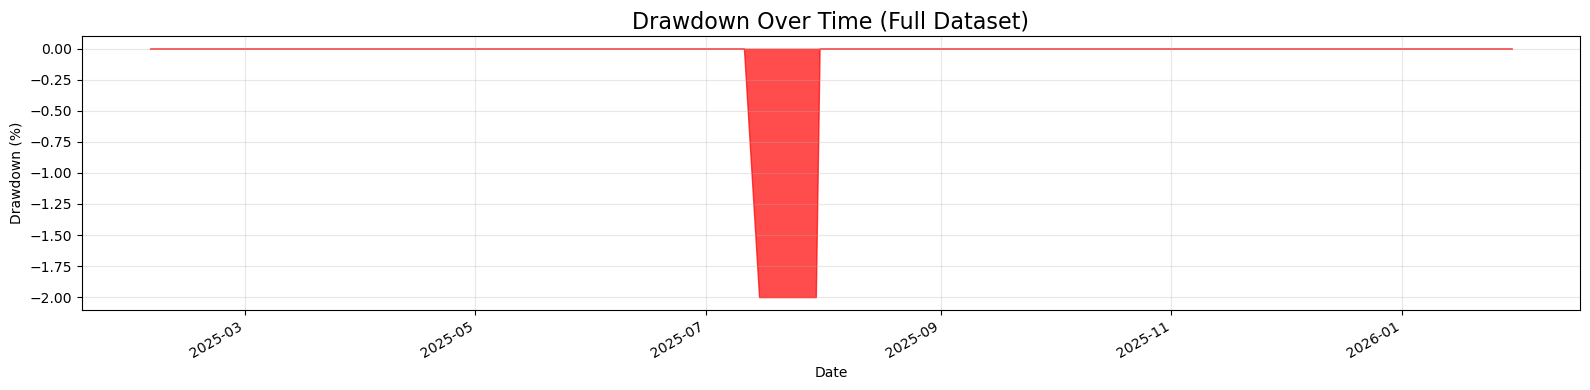

In [12]:
## 10. Plot Equity Curve (Full Dataset)
# Create equity curve dataframe with dates
equity_dates = renko_df['Date'].iloc[1:len(equity_curve)+1].reset_index(drop=True)
if len(equity_dates) < len(equity_curve):
    equity_dates = pd.concat([equity_dates, pd.Series([renko_df['Date'].iloc[-1]] * (len(equity_curve) - len(equity_dates)))]).reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(equity_dates, equity_curve, label='Equity Curve', color='blue', linewidth=2)
plt.axhline(y=initial_capital, color='gray', linestyle='--', label='Initial Capital')
plt.title('Strategy Equity Curve (Full Dataset) - Long & Short Trades', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Capital ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

## 11. Plot Drawdown (Full Dataset)
# Use the same equity_dates from previous cell
drawdown_dates = equity_dates[:len(drawdown)]

plt.figure(figsize=(16, 4))
plt.fill_between(drawdown_dates, drawdown[:len(drawdown_dates)] * 100, color='red', alpha=0.7)
plt.title('Drawdown Over Time (Full Dataset)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [13]:
## 12. Trade Log Summary (Full Dataset)
# Display trade log as DataFrame
if trade_log:
    trade_log_df = pd.DataFrame(trade_log)
    
    # Format dates
    if 'Entry_Date' in trade_log_df.columns:
        trade_log_df['Entry_Date'] = pd.to_datetime(trade_log_df['Entry_Date']).dt.strftime('%Y-%m-%d')
    if 'Exit_Date' in trade_log_df.columns:
        trade_log_df['Exit_Date'] = pd.to_datetime(trade_log_df['Exit_Date']).dt.strftime('%Y-%m-%d')
    
    # Add profit/loss indicator
    trade_log_df['Result'] = trade_log_df['PnL'].apply(
        lambda x: '✅ WIN' if x > 0 else ('❌ LOSS' if x < 0 else '➖ BE') if pd.notna(x) else '⏳ OPEN'
    )
    
    # Format R:R ratio
    if 'RR_Ratio' in trade_log_df.columns:
        trade_log_df['R:R'] = trade_log_df['RR_Ratio'].apply(lambda x: f"{x:.2f}R" if pd.notna(x) else "N/A")
    
    # Reorder columns
    cols = ['Type', 'Entry_Date', 'Entry_Brick', 'Entry_Price', 'Exit_Date', 'Exit_Brick', 
            'Exit_Price', 'Size', 'PnL', 'R:R', 'Capital', 'Result']
    cols = [c for c in cols if c in trade_log_df.columns]
    trade_log_df = trade_log_df[cols]
    
    display(trade_log_df)
    
    # Summary by trade type
    print("\n" + "=" * 60)
    print("              TRADE SUMMARY BY TYPE")
    print("=" * 60)
    
    for trade_type in ['LONG', 'SHORT']:
        type_trades = [t for t in trade_log if t['Type'] == trade_type and 'PnL' in t]
        if type_trades:
            type_pnl = sum(t['PnL'] for t in type_trades)
            type_wins = len([t for t in type_trades if t['PnL'] > 0])
            type_losses = len([t for t in type_trades if t['PnL'] < 0])
            type_win_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) > 0 and 'RR_Ratio' in t]
            type_loss_rr = [t['RR_Ratio'] for t in type_trades if t.get('PnL', 0) < 0 and 'RR_Ratio' in t]
            
            print(f"\n{trade_type} Trades:")
            print(f"  Total: {len(type_trades)}")
            print(f"  Wins: {type_wins} | Losses: {type_losses}")
            print(f"  Total PnL: ${type_pnl:,.2f}")
            print(f"  Avg Winning R:R: {np.mean(type_win_rr):.2f}R" if type_win_rr else "  Avg Winning R:R: N/A")
            print(f"  Avg Losing R:R: {np.mean(type_loss_rr):.2f}R" if type_loss_rr else "  Avg Losing R:R: N/A")
        else:
            print(f"\n{trade_type} Trades: None")
    
    # Streak Analysis
    print("\n" + "=" * 60)
    print("              STREAK ANALYSIS")
    print("=" * 60)
    print(f"Maximum Winning Streak: {max_win_streak} consecutive trades")
    print(f"Maximum Losing Streak:  {max_loss_streak} consecutive trades")
    
else:
    print("No trades executed.")

,Type,Entry_Date,Entry_Brick,Entry_Price,Exit_Date,Exit_Brick,Exit_Price,Size,PnL,R:R,Capital,Result
0,LONG,2025-05-08,276,5662.25,2025-05-21,299,5947.25,6.666667,1900.000000,19.00R,11900.000000,✅ WIN
1,LONG,2025-06-06,323,5977.25,2025-06-13,329,6007.25,7.933333,238.000000,2.00R,12138.000000,✅ WIN
2,LONG,2025-06-23,336,6022.25,2025-07-04,358,6292.25,8.092000,2184.840000,18.00R,14322.840000,✅ WIN
3,LONG,2025-07-10,362,6322.25,2025-07-15,364,6292.25,9.548560,-286.456800,-2.00R,14036.383200,❌ LOSS
4,LONG,2025-07-17,366,6322.25,2025-07-31,374,6382.25,9.357589,561.455328,4.00R,14597.838528,✅ WIN
5,LONG,2025-08-22,405,6427.25,2025-08-29,415,6487.25,9.731892,583.913541,4.00R,15181.752069,✅ WIN
6,LONG,2025-09-03,420,6442.25,2025-09-24,442,6712.25,10.121168,2732.715372,18.00R,17914.467442,✅ WIN
7,LONG,2025-09-29,447,6697.25,2025-10-10,457,6757.25,11.942978,716.578698,4.00R,18631.046139,✅ WIN
8,LONG,2025-10-20,478,6712.25,2025-10-22,484,6742.25,12.420697,372.620923,2.00R,19003.667062,✅ WIN
9,LONG,2025-10-23,486,6772.25,2025-10-30,498,6892.25,12.669111,1520.293365,8.00R,20523.960427,✅ WIN



              TRADE SUMMARY BY TYPE

LONG Trades:
  Total: 12
  Wins: 11 | Losses: 1
  Total PnL: $11,985.27
  Avg Winning R:R: 7.82R
  Avg Losing R:R: -2.00R

SHORT Trades: None

              STREAK ANALYSIS
Maximum Winning Streak: 8 consecutive trades
Maximum Losing Streak:  1 consecutive trades


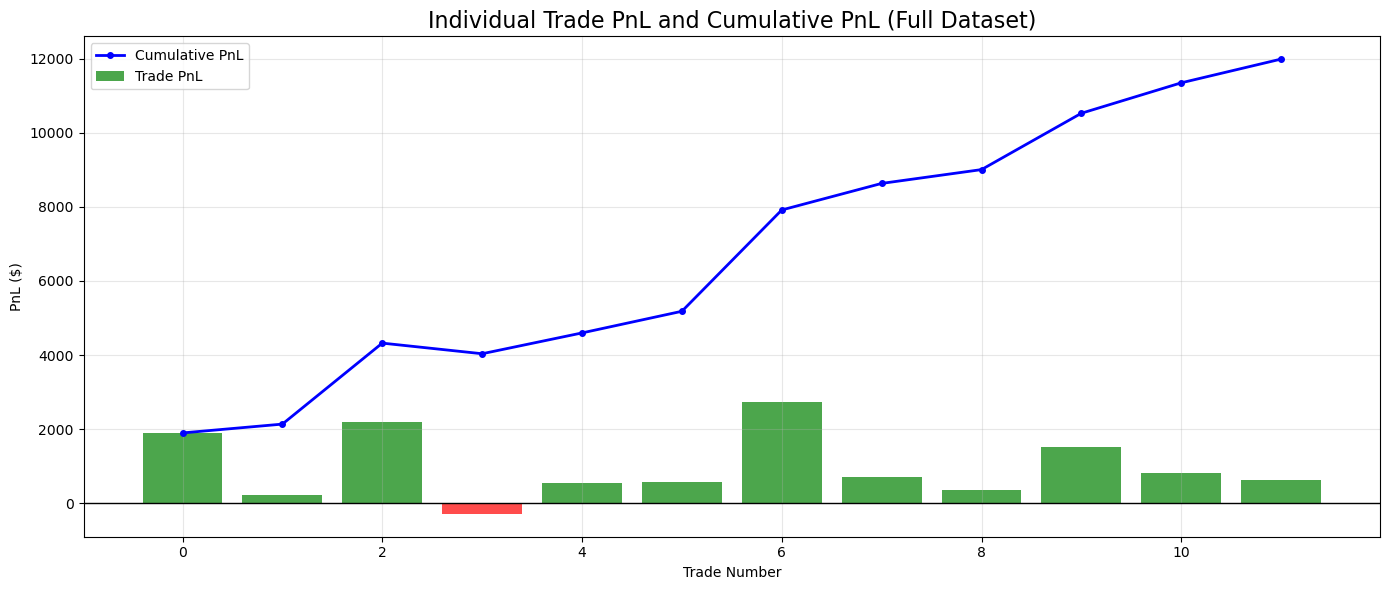

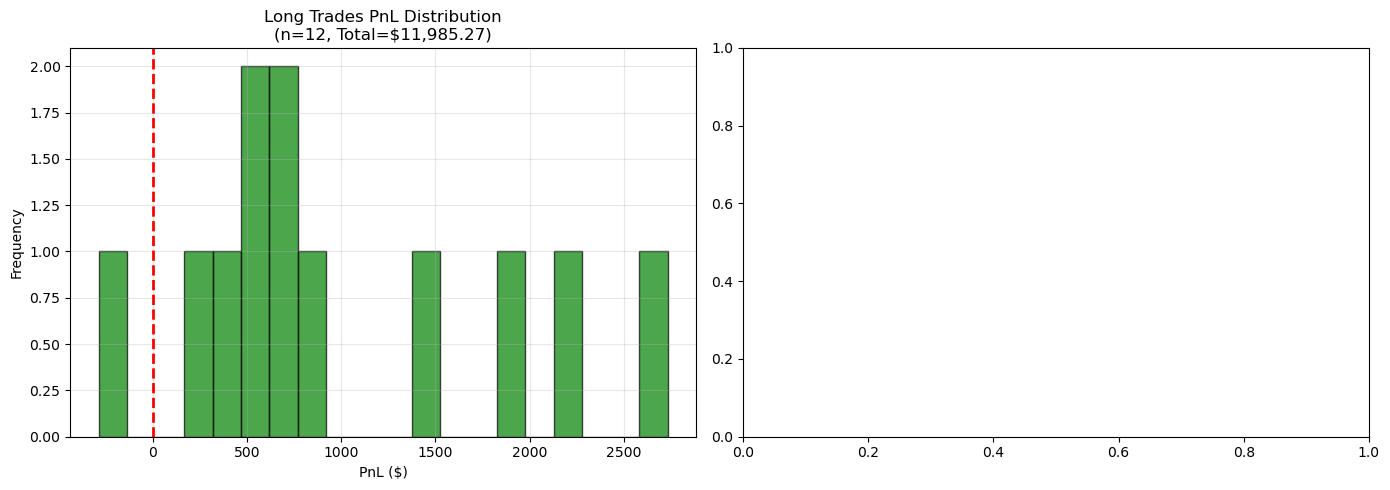

In [14]:
## 13. Monthly/Yearly Performance Breakdown
# Create a DataFrame to analyze trades over time
if trade_log:
    trade_analysis_df = pd.DataFrame(trade_log)
    
    # Calculate cumulative PnL
    trade_analysis_df['Cumulative_PnL'] = trade_analysis_df['PnL'].cumsum()
    
    # Plot cumulative PnL by trade number
    plt.figure(figsize=(14, 6))
    
    colors = ['green' if x > 0 else 'red' for x in trade_analysis_df['PnL']]
    
    plt.bar(range(len(trade_analysis_df)), trade_analysis_df['PnL'], color=colors, alpha=0.7, label='Trade PnL')
    plt.plot(range(len(trade_analysis_df)), trade_analysis_df['Cumulative_PnL'], 
             color='blue', linewidth=2, marker='o', markersize=4, label='Cumulative PnL')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.title('Individual Trade PnL and Cumulative PnL (Full Dataset)', fontsize=16)
    plt.xlabel('Trade Number')
    plt.ylabel('PnL ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Long vs Short performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Long trades PnL distribution
    long_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'LONG' and 'PnL' in t]
    if long_pnls:
        axes[0].hist(long_pnls, bins=20, color='green', alpha=0.7, edgecolor='black')
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[0].set_title(f'Long Trades PnL Distribution\n(n={len(long_pnls)}, Total=${sum(long_pnls):,.2f})')
        axes[0].set_xlabel('PnL ($)')
        axes[0].set_ylabel('Frequency')
        axes[0].grid(True, alpha=0.3)
    
    # Short trades PnL distribution
    short_pnls = [t['PnL'] for t in trade_log if t['Type'] == 'SHORT' and 'PnL' in t]
    if short_pnls:
        axes[1].hist(short_pnls, bins=20, color='magenta', alpha=0.7, edgecolor='black')
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
        axes[1].set_title(f'Short Trades PnL Distribution\n(n={len(short_pnls)}, Total=${sum(short_pnls):,.2f})')
        axes[1].set_xlabel('PnL ($)')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No trades to analyze.")